In [4]:
import requests
from bs4 import BeautifulSoup
import re

### 영화 제목,평점, 개봉 날짜 웹스크래핑 함수

In [5]:
def get_all_movie():
    url = "http://www.cgv.co.kr/movies/?lt=1&ft=1"
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/135.0.0.0 Safari/537.36 Edg/135.0.0.0'}

    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')

    movie_list = soup.select('div.sect-movie-chart > ol > li')

    for movie in movie_list:
        title = movie.select_one('div.box-contents strong.title')
        percent = movie.select_one('div.box-contents strong.percent')
        info = movie.select_one('div.box-contents span.txt-info')
        
        title_text = title.get_text(strip=True) if title else 'N/A'
        percent_text = percent.get_text(strip=True) if percent else 'N/A'
        info_text = info.get_text(strip=True) if info else 'N/A'
        
        return title_text, percent_text, info_text

### 영화 매력/감정 포인트 불러오기 함수

In [2]:
# 저는 edge를 사용해서 chrome 사용하시는분들 수정하시면 됩니다.
from selenium import webdriver
from selenium.webdriver.edge.service import Service as EdgeService
from selenium.webdriver.edge.options import Options as EdgeOptions
from selenium.webdriver.common.by import By
import time
import re

def find_review(midx):
    options = EdgeOptions()
    options.add_argument('--headless') 
    options.add_argument('--disable-gpu')
    options.add_argument("window-size=1920x1080")
    options.add_argument("user-agent=Mozilla/5.0")

    # 본인 dirver_path에 맞춰춰 수정하시면 됩니다.
    driver_path = "C:/miniProject/msedgedriver.exe"
    driver = webdriver.Edge(service=EdgeService(driver_path), options=options)

    url = f"http://www.cgv.co.kr/movies/detail-view/?midx={midx}"
    driver.get(url)
    time.sleep(2)


    circles = driver.find_elements(By.CSS_SELECTOR, "div.amcharts-main-div svg g g circle")

    charm_points = {}   # 매력 포인트
    emotion_points = {} # 감정 포인트

    idx = 0
    for circle in circles:
        aria = circle.get_attribute("aria-label")
        if aria:
            match = re.search(r'(.*)\s(\d+)$', aria.strip())
            if match:
                key = match.group(1).strip()
                value = int(match.group(2))
                if idx < 5:
                    charm_points[key] = value
                else:
                    emotion_points[key] = value
                idx += 1

    print("매력 포인트:", charm_points)
    print("감정 포인트:", emotion_points)

    return charm_points, emotion_points
    driver.quit()

# midx 예시
find_review(89454)


매력 포인트: {'감독연출': 44, '스토리': 60, '영상미': 24, '배우연기': 87, 'OST': 13}
감정 포인트: {'스트레스 해소': 38, '현실감': 44, '긴장감': 43, '몰입감': 75, '무서움': 17}


({'감독연출': 44, '스토리': 60, '영상미': 24, '배우연기': 87, 'OST': 13},
 {'스트레스 해소': 38, '현실감': 44, '긴장감': 43, '몰입감': 75, '무서움': 17})

### 매력/감정 포인트 시각화 그래프

매력 포인트: {'감독연출': 44, '스토리': 60, '영상미': 24, '배우연기': 87, 'OST': 13}
감정 포인트: {'스트레스 해소': 38, '현실감': 44, '긴장감': 43, '몰입감': 75, '무서움': 17}


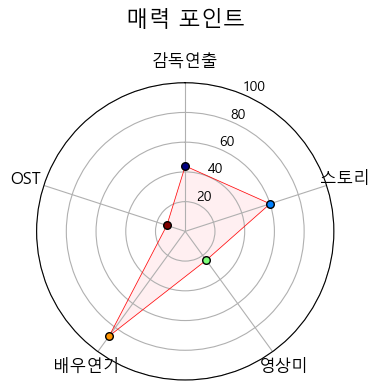

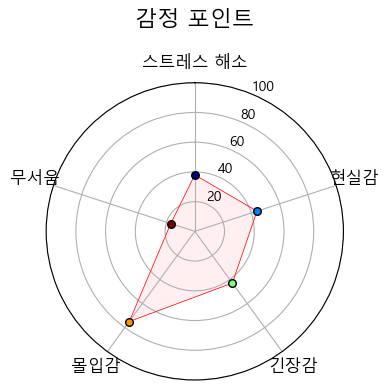

In [6]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# 한글폰트 깨지는거 인코딩딩
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def draw_radar_chart(data_dict, title):
    labels = list(data_dict.keys())
    values = list(data_dict.values())

    num_vars = len(labels)

    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    values += values[:1]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(4, 4), subplot_kw=dict(polar=True))

    ax.plot(angles, values, color='red', linewidth=0.5)
    ax.fill(angles, values, color='pink', alpha=0.25)


    colors = plt.cm.jet(np.linspace(0, 1, len(values)-1))

    for i in range(len(values)-1):
        ax.scatter(angles[i], values[i], color=colors[i], s=30, edgecolor='black', zorder=5)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=12)

    ax.set_title(title, size=16, pad=20)
    ax.set_ylim(0, 100)

    plt.tight_layout()
    plt.show()

charm_points, emotion_points = find_review(89454)

draw_radar_chart(charm_points, "매력 포인트")
draw_radar_chart(emotion_points, "감정 포인트")


### 영화 midx 가져오기 함수

In [11]:
def get_all_midx():
    url = "http://www.cgv.co.kr/movies/?lt=1&ft=1"
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/135.0.0.0 Safari/537.36 Edg/135.0.0.0'
    }

    res = requests.get(url, headers=headers)
    soup = BeautifulSoup(res.text, 'html.parser')

    movies = soup.select('div.sect-movie-chart > ol > li')

    midx_dict = {}

    for movie in movies:
        link_tag = movie.select_one('div.box-contents a')
        title_tag = movie.select_one('div.box-contents strong.title')
        
        if link_tag and title_tag:
            href = link_tag['href']
            title = title_tag.get_text(strip=True)
            match = re.search(r"midx=(\d+)", href)
            if match:
                midx = match.group(1)
                midx_dict[title] = midx

    return midx_dict

get_all_midx()


{'야당': '89454',
 '승부': '89485',
 '사유리': '89549',
 '플로우': '89450',
 '마리아': '89513',
 '브리짓 존스의 일기: 뉴 챕터': '89362',
 '탑건-매버릭': '82120',
 '드라이브 인 타이페이': '89451',
 '퇴마록': '89386',
 '세븐틴 [라잇 히어] 월드 투어 인 시네마': '89544',
 '스윙걸즈': '89499',
 '위키드': '88076',
 '어른 김장하': '87547',
 '너의 새는 노래 할 수 있어': '83156',
 '아마추어': '89546',
 '베러맨': '89517',
 '콘클라베': '89425',
 '예언자': '89501',
 '와일드 로봇': '88137'}

### 영화 상세정보 함수


In [15]:
def get_movie_info(midx):
    url = f"http://www.cgv.co.kr/movies/detail-view/?midx={midx}"
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/135.0.0.0 Safari/537.36 Edg/135.0.0.0'
    }

    res = requests.get(url, headers=headers)
    soup = BeautifulSoup(res.text, 'html.parser')

    movie_detail = soup.select_one('div.wrap-movie-detail')
    if movie_detail:
        title = movie_detail.select_one('div.sect-base-movie div > strong')
        percent = movie_detail.select_one('div.sect-base-movie strong.percent')
        info = movie_detail.select_one('div.sect-base-movie div.spec')
        story = movie_detail.select_one('div.sect-story-movie')
        image_tag = movie_detail.select_one('div.box-image span.thumb-image img')

        title_text = title.get_text(strip=True) if title else 'N/A'
        percent_text = percent.get_text(strip=True) if percent else 'N/A'
        info_text = info.get_text(strip=True) if info else 'N/A'
        story_text = story.get_text(strip=True) if story else 'N/A'
        image_url = image_tag['src'] if image_tag else None


        print(f"영화 제목: {title_text}")
        print(f"예매율: {percent_text}")
        print(f"정보: {info_text}")
        print(f"줄거리: {story_text}")

        if image_url:
            print("포스터:")
            display(Image(url=image_url))

        return title_text, percent_text, info_text, story_text, image_url

get_movie_info(89454)  # 예시로 midx 89454

영화 제목: 야당
예매율: 예매율35.4%
정보: 감독 :황병국/ 배우 :강하늘,유해진,박해준,류경수,채원빈장르 : 범죄, 액션/ 기본 정보 :청소년관람불가, 123분, 한국개봉 :2025.04.16
줄거리: 대한민국 마약 수사의 뒷거래모든 것은 야당으로부터 시작된다!누명을 쓰고 교도소에 수감된 이강수(강하늘)는검사 구관희(유해진)로부터 감형을 조건으로 야당을 제안받는다.강수는 관희의 야당이 돼 마약 수사를 뒤흔들기 시작하고,출세에 대한 야심이 가득한 관희는굵직한 실적을 올려 탄탄대로의 승진을 거듭한다.한편, 마약수사대 형사 오상재(박해준)는수사 과정에서 강수의 야당질로 번번이 허탕을 치고,끈질긴 집념으로 강수와 관희의 관계를 파고든다.마약판을 설계하는 브로커 강수,더 높은 곳에 오르려는 관희, 마약 범죄 소탕에 모든 것을 건 상재.세 사람은 각자 다른 이해관계로 얽히기 시작하는데…
포스터:


('야당',
 '예매율35.4%',
 '감독 :황병국/ 배우 :강하늘,유해진,박해준,류경수,채원빈장르 :\xa0범죄,\xa0액션/ 기본 정보 :청소년관람불가,\xa0123분,\xa0한국개봉 :2025.04.16',
 '대한민국 마약 수사의 뒷거래모든 것은 야당으로부터 시작된다!누명을 쓰고 교도소에 수감된 이강수(강하늘)는검사 구관희(유해진)로부터 감형을 조건으로 야당을 제안받는다.강수는 관희의 야당이 돼 마약 수사를 뒤흔들기 시작하고,출세에 대한 야심이 가득한 관희는굵직한 실적을 올려 탄탄대로의 승진을 거듭한다.한편, 마약수사대 형사 오상재(박해준)는수사 과정에서 강수의 야당질로 번번이 허탕을 치고,끈질긴 집념으로 강수와 관희의 관계를 파고든다.마약판을 설계하는 브로커 강수,더 높은 곳에 오르려는 관희, 마약 범죄 소탕에 모든 것을 건 상재.세 사람은 각자 다른 이해관계로 얽히기 시작하는데…',
 'https://img.cgv.co.kr/Movie/Thumbnail/Poster/000089/89454/89454_320.jpg')